In [1]:
using Oceananigans
using JLD2
using CairoMakie
using CairoMakie.Colors

using Statistics

include("../src-fig/figures/preinitial_conditions.jl")
include("../src-simulation/parameters.jl")
include("../src-simulation/base_state.jl")
include("../src-simulation/grid_faces.jl")

include("../src-fig/plotting.jl")
include("../setup/ensemble.jl");

[ Info: Oceananigans will use 4 threads


# Mixed layer average
We define an average over the mixed layer,
$$
\langle \overline b \rangle = \frac{1}{h(x, t)}\int_{-h}^0\overline{b}\,\text{d}z,
$$
where the mixed layer depth $h$ is arbitrary for now. This further decomposes the flow
$$
b = \overline{b} + b' = \langle \overline b\rangle + b^\dagger + b'
$$
Where
$$
b' = b - \overline b\quad \text{and} \quad b^\dagger = \overline b - \langle \overline{b}\rangle
$$
The frontal width is found for the near-surface, mixed-layer-average and domain-averaged buoyancies.

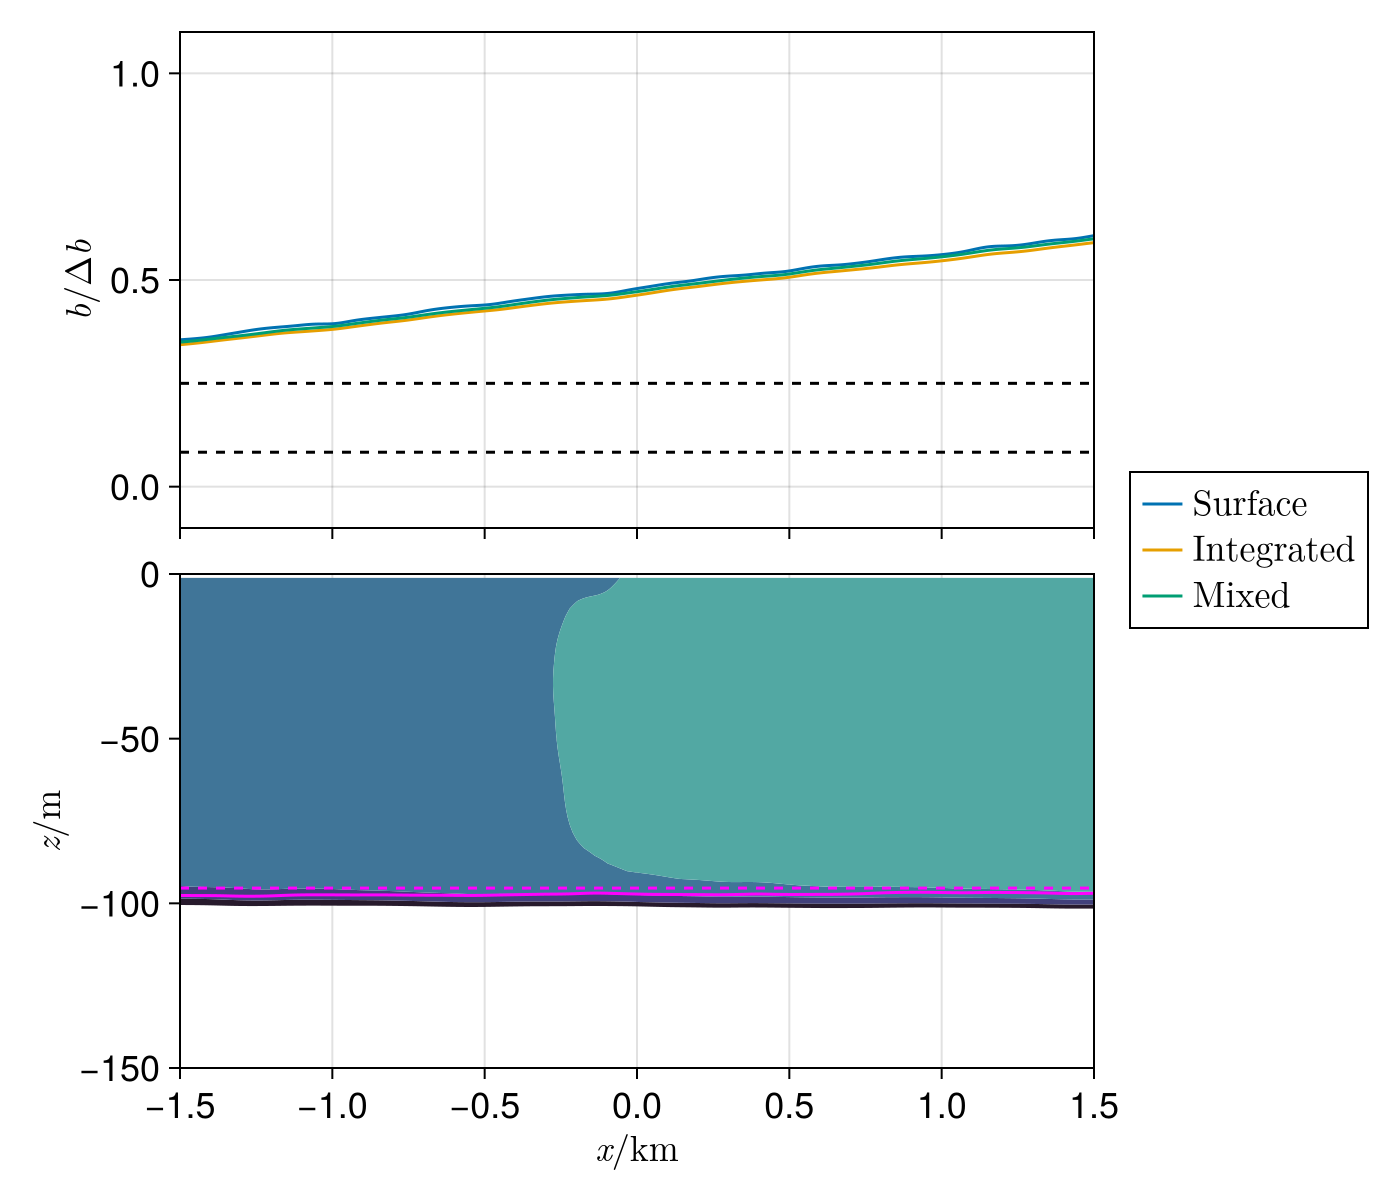

In [2]:
i = 1

run_ids = cooling_only.filenames
run_id = run_ids[i]

foldername = joinpath("../../scratch/turbulence-at-many-fronts", run_id)
COARSE = joinpath(foldername, "COARSE.jld2")
MLD = joinpath(foldername, "MLD.jld2")
iterations, times = iterations_times(COARSE)
sp = simulation_parameters(COARSE)
xsᶜ, xsᶠ, ysᶜ, ysᶠ, zsᶜ, zsᶠ = grid_nodes(COARSE)
k1, k2 = zᶜbounds(COARSE, -sp.H, -5)

n = 10

fig = Figure(; 
    size = (700, 600),
    fontsize = 18,
)

ax = Axis(fig[2, 1];
    xlabel = L"x / \text{km}",
    ylabel = L"z / \text{m}",
    limits = (-sp.Lh/2000, sp.Lh/2000, -sp.Lz, 0)
)

b = get_field(COARSE, "b_coarse", iterations[n]) do field
    field ./ sp.Δb
end

mld = get_field(MLD, "mld", iterations[n])

b_mld = get_field(MLD, "b_coarse_constant_mld", iterations[n]) do field
    field ./ sp.Δb
end
b = b .- mean(b[:, k1:k2])
bl = 1/12
br = bl + 1/6


contourf!(ax, xsᶜ ./ 1000, zsᶜ, b, levels=-0.5:0.166:0.5, colormap=reverse(to_colormap(:deep)))
#contour!(ax, xsᶜ ./ 1000, zsᶜ, b, levels=[bl, br], color=:red)
lines!(ax,  xsᶜ ./ 1000, -mld; color=:magenta)
lines!(ax,  [-sp.Lx, sp.Lx] ./ 2000, [-minimum(mld), -minimum(mld)]; color=:magenta, linestyle=:dash)

ax = Axis(fig[1, 1];
    xlabel = L"x / \text{km}",
    ylabel = L"b/\Delta b",
    limits = (-sp.Lh/2000, sp.Lh/2000, -0.1, 1.1),
    yticks = [-1, -0.5, 0, 0.5, 1]
)
hidexdecorations!(ax; ticks=false, grid=false)
b_integrated = mean(b[:, k1:k2]; dims=2)[:, 1]
b_surface = b[:, k2]

lns = [
    lines!(ax, xsᶜ ./ 1000, b_surface .- minimum(b_surface)),
    lines!(ax, xsᶜ ./ 1000, b_integrated .- minimum(b_integrated)),
    lines!(ax, xsᶜ ./ 1000, b_mld .- minimum(b_mld))
]
lines!(ax, [-sp.Lx/2000, sp.Lx/2000], [bl, bl]; color=:black, linestyle=:dash)
lines!(ax, [-sp.Lx/2000, sp.Lx/2000], [br, br]; color=:black, linestyle=:dash)
Legend(fig[1:2, 2], lns, [L"\text{Surface}", L"\text{Integrated}", L"\text{Mixed}"])
fig

In [5]:
function mixed_layer_average(run_id, frames=nothing)
    foldername = joinpath("../../scratch/turbulence-at-many-fronts", run_id)
    COARSE = joinpath(foldername, "COARSE.jld2")
    MLD = joinpath(foldername, "MLD.jld2")

    iterations, times = iterations_times(COARSE)
    sp = simulation_parameters(COARSE)
    xsᶜ, xsᶠ, ysᶜ, ysᶠ, zsᶜ, zsᶠ = grid_nodes(COARSE)
    frames = isnothing(frames) ? (1:length(times)) : frames
    
    n = Observable(1)
    t = @lift times[$n]
    
    U = @lift [100velocity_profile(x, sp) * variable_strain_rate($t, sp) for x in xsᶠ, z in 1:1]
    
    u = @lift get_field(COARSE, "u_coarse", iterations[$n]) .* 100 .+ $U
    u_mld = @lift get_field(MLD, "u_coarse_mld", iterations[$n]) .* 100 .+ $U[:, 1]

    v = @lift get_field(COARSE, "v_coarse", iterations[$n]) .* 100
    v_mld = @lift get_field(MLD, "v_coarse_mld", iterations[$n]) .* 100


    b_offset = @lift get_field(MLD, "b_coarse_mld", iterations[$n]) do field
        minimum(field)
    end
    
    b = @lift get_field(COARSE, "b_coarse", iterations[$n]) do field
        (field .- $b_offset) ./ sp.Δb
    end
    
    b_mld = @lift get_field(MLD, "b_coarse_mld", iterations[$n]) do field
        (field .- $b_offset) ./ sp.Δb
    end

    mld = @lift get_field(MLD, "mld", iterations[$n])
    hs = @lift [z + h for h in $mld, z in zsᶠ]

    u_dag = @lift $u .- reshape($u_mld, size($u_mld, 1), 1)
    v_dag = @lift $v .- reshape($v_mld, size($v_mld, 1), 1)
    b_dag = @lift $b .- reshape($b_mld, size($b_mld, 1), 1)

    
    fig = Figure(; 
        size = (1200, 600),
        fontsize = 18,
    )
    
    ax_u_ml = Axis(fig[1, 1];
        xlabel = L"x / \text{km}",
        ylabel = L"\langle u\rangle / \text{cm}\,\text{s}^{-1}",
        limits = (-sp.Lh/2000, sp.Lh/2000, -3, 3)
    )
    hidexdecorations!(ax_u_ml; ticks=false)

    ax_v_ml = Axis(fig[1, 2];
        xlabel = L"x / \text{km}",
        ylabel = L"\langle v\rangle / \text{cm}\,\text{s}^{-1}",
        limits = (-sp.Lh/2000, sp.Lh/2000, -1, 15)
    )
    hidexdecorations!(ax_v_ml; ticks=false)

    ax_b_ml = Axis(fig[1, 3];
        xlabel = L"x / \text{km}",
        ylabel = L"\langle b\rangle / \Delta b",
        limits = (-sp.Lh/2000, sp.Lh/2000, -0.1, 1.1)
    )
    hidexdecorations!(ax_b_ml; ticks=false)

    ax_u = Axis(fig[2, 1];
        xlabel = L"x / \text{km}",
        ylabel = L"z / \text{m}",
        limits = (-sp.Lh/2000, sp.Lh/2000, -sp.Lz, 0)
    )
    
    ax_v = Axis(fig[2, 2];
        xlabel = L"x / \text{km}",
        ylabel = L"z / \text{m}",
        limits = (-sp.Lh/2000, sp.Lh/2000, -sp.Lz, 0)
    )
    hideydecorations!(ax_v; ticks=false)
    
    ax_b = Axis(fig[2, 3];
        xlabel = L"x / \text{km}",
        ylabel = L"z / \text{m}",
        limits = (-sp.Lh/2000, sp.Lh/2000, -sp.Lz, 0)
    )
    hideydecorations!(ax_b; ticks=false)

    lines!(ax_u_ml, xsᶠ ./ 1000, u_mld)
    lines!(ax_v_ml, xsᶜ ./ 1000, v_mld)
    lines!(ax_b_ml, xsᶜ ./ 1000, b_mld)
    
    ht_u = heatmap!(ax_u, xsᶠ ./ 1000, zsᶜ, u_dag; colormap=:balance, colorrange=(-3, 3))
    ht_v = heatmap!(ax_v, xsᶜ ./ 1000, zsᶜ, v_dag; colormap=:balance, colorrange=(-15, 15))
    ht_b = heatmap!(ax_b, xsᶜ ./ 1000, zsᶜ, b_dag; colormap=:balance, colorrange=(-1, 1))

    #lines!(ax_u, xsᶜ ./ 1000, h; color=:magenta)
    #lines!(ax_v, xsᶜ ./ 1000, h; color=:magenta)
    #lines!(ax_b, xsᶜ ./ 1000, h; color=:magenta)

    contourf!(ax_u, xsᶜ ./ 1000, zsᶠ, hs; levels=[-2sp.Lz, 0, 2sp.Lz], colormap=[RGBA(0.3, 0.3, 0.3, 1.0), RGBA(0.3, 0.3, 0.3, 0.0)])
    contourf!(ax_v, xsᶜ ./ 1000, zsᶠ, hs; levels=[-2sp.Lz, 0, 2sp.Lz], colormap=[RGBA(0.3, 0.3, 0.3, 1.0), RGBA(0.3, 0.3, 0.3, 0.0)])
    contourf!(ax_b, xsᶜ ./ 1000, zsᶠ, hs; levels=[-2sp.Lz, 0, 2sp.Lz], colormap=[RGBA(0.3, 0.3, 0.3, 1.0), RGBA(0.3, 0.3, 0.3, 0.0)])

    Colorbar(fig[3, 1], ht_u; label=L"u^\dagger / \text{cm}\,\text{s}^{-1}", vertical=false, flipaxis=false)
    Colorbar(fig[3, 2], ht_v; label=L"v^\dagger / \text{cm}\,\text{s}^{-1}", vertical=false, flipaxis=false)
    Colorbar(fig[3, 3], ht_b; label=L"b^\dagger / \Delta b", vertical=false, flipaxis=false)
    
    filename = joinpath("..", "figures", "video", "cooling-only", "mld-$run_id.mp4")
    prettyrecord(n, fig, filename, frames; px_per_unit=2, framerate=12)
    fig
end

for run_id in cooling_only.filenames
    mixed_layer_average(run_id)
end

298s / 298s (334 / 334)
293s / 293s (334 / 334)
291s / 291s (334 / 334)
294s / 294s (334 / 334)
294s / 294s (334 / 334)
294s / 294s (334 / 334)
295s / 295s (334 / 334)
294s / 294s (334 / 334)
295s / 295s (334 / 334)
296s / 296s (334 / 334)
296s / 296s (334 / 334)
293s / 293s (334 / 334)
293s / 293s (334 / 334)
292s / 292s (334 / 334)
292s / 292s (334 / 334)
292s / 292s (334 / 334)


In [34]:
run_ids = cooling_only.filenames
avg_ℓs = map(run_ids) do run_id
    foldername = joinpath("../../scratch/turbulence-at-many-fronts", run_id)
    COARSE = joinpath(foldername, "COARSE.jld2")
    ilr, xlr, ℓ = average_front_width(COARSE)
    ℓ
end
surface_ℓs = map(run_ids) do run_id
    foldername = joinpath("../../scratch/turbulence-at-many-fronts", run_id)
    COARSE = joinpath(foldername, "COARSE.jld2")
    ilr, xlr, ℓ = surface_front_width(COARSE)
    ℓ
end
mixed_ℓs = map(run_ids) do run_id
    foldername = joinpath("../../scratch/turbulence-at-many-fronts", run_id)
    MLD = joinpath(foldername, "MLD.jld2")
    ilr, xlr, ℓ = mixed_front_width(MLD)
    ℓ
end;

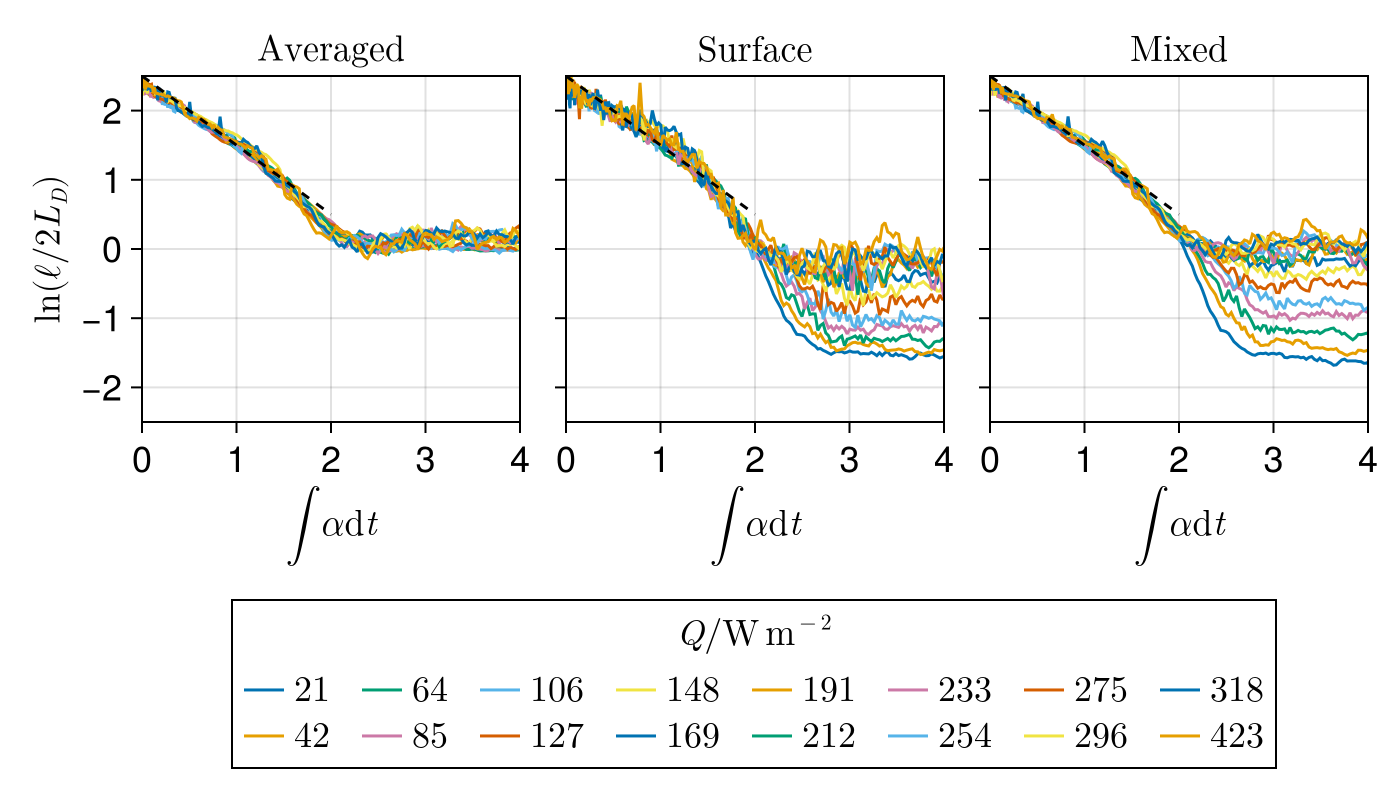

In [35]:
fig = Figure(; size=(700, 400), fontsize=18)
ax_avg = Axis(fig[1, 1];
    xlabel = L"\int \alpha \text{d}t",
    ylabel = L"\ln (\ell / 2L_D)",
    title = L"\text{Averaged}",
    limits = (0, 4, -2.5, 2.5),
    yticks = [-2, -1, 0, 1, 2]
)

ax_surface = Axis(fig[1, 2];
    xlabel = L"\int \alpha \text{d}t",
    ylabel = L"\ln (\ell / 2L_D)",
    title = L"\text{Surface}",
    limits = (0, 4, -2.5, 2.5),
    yticks = [-2, -1, 0, 1, 2]
)
hideydecorations!(ax_surface; ticks=false, grid=false)

ax_mixed = Axis(fig[1, 3];
    xlabel = L"\int \alpha \text{d}t",
    ylabel = L"\ln (\ell / 2L_D)",
    title = L"\text{Mixed}",
    limits = (0, 4, -2.5, 2.5),
    yticks = [-2, -1, 0, 1, 2]
)
hideydecorations!(ax_mixed; ticks=false, grid=false)

lns = map(1:length(run_ids)) do i
    foldername = joinpath("../../scratch/turbulence-at-many-fronts", run_ids[i])
    COARSE = joinpath(foldername, "COARSE.jld2")
    iterations, times = iterations_times(COARSE)
    sp = simulation_parameters(COARSE)
    s = normalized_time(COARSE)
    
    lines!(ax_avg, s, log.(avg_ℓs[i] ./ 2sp.L))
    lines!(ax_surface, s, log.(surface_ℓs[i] ./ 2sp.L))
    lines!(ax_mixed, s, log.(mixed_ℓs[i] ./ 2sp.L))
end
Qs = map(1:length(run_ids)) do i
    foldername = joinpath("../../scratch/turbulence-at-many-fronts", run_ids[i])
    COARSE = joinpath(foldername, "COARSE.jld2")
    iterations, times = iterations_times(COARSE)
    sp = simulation_parameters(COARSE)
    Q_str = @sprintf "%.0f" sp.Q
    L"%$Q_str"
end
lines!(ax_surface, 0:2, x->2.5-x; color=:black, linestyle=:dash)
lines!(ax_avg, 0:2, x->2.5-x; color=:black, linestyle=:dash)
lines!(ax_mixed, 0:2, x->2.5-x; color=:black, linestyle=:dash)
Legend(fig[2, 1:3], lns, Qs, L"Q / \text{W}\,\text{m}^{-2}"; orientation=:horizontal, nbanks=2)
fig

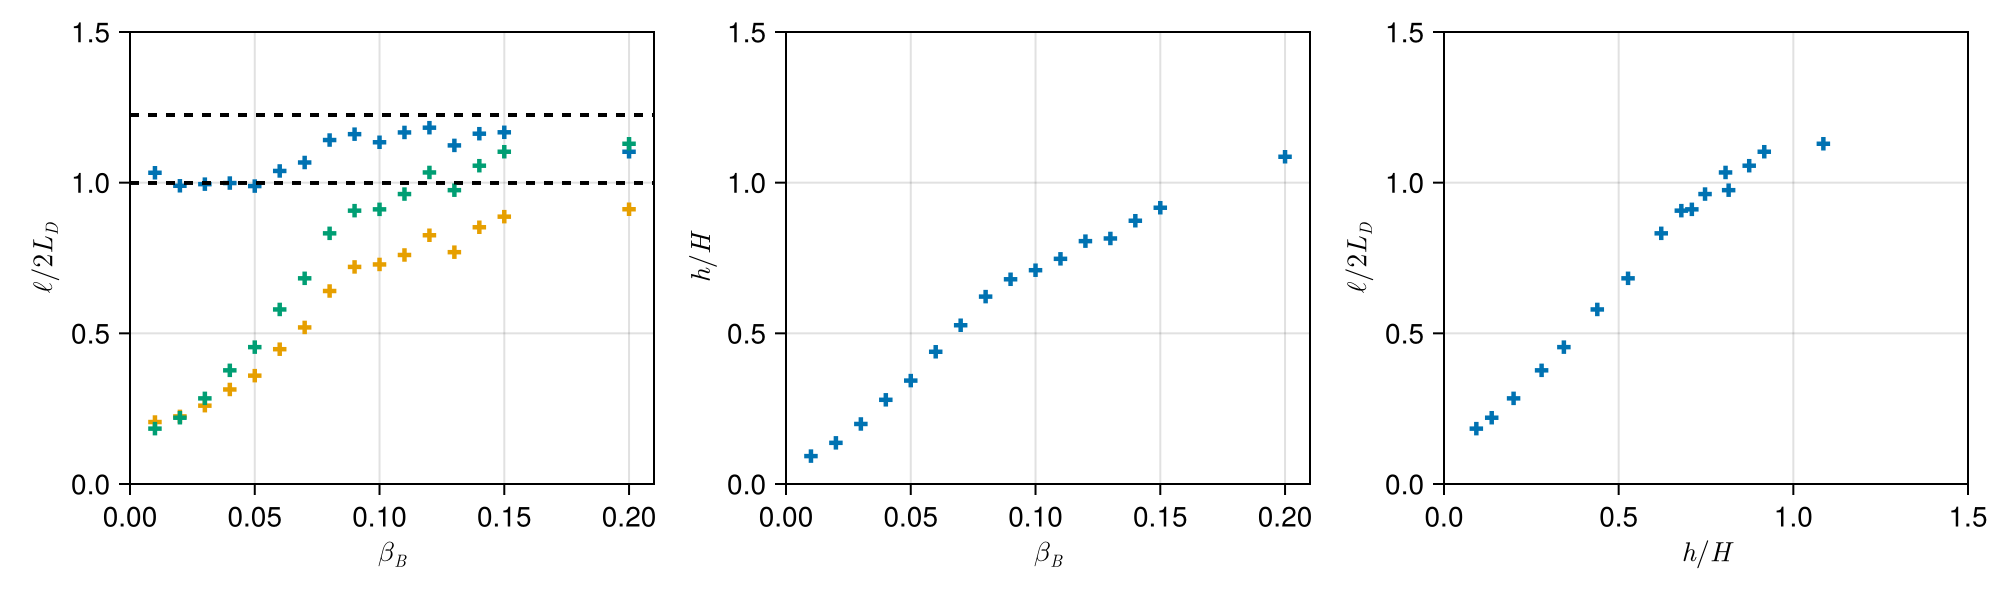

In [43]:
fig = Figure(; size=(1000, 300))
ax_ℓ = Axis(fig[1, 1];
    xlabel = L"\beta_B",
    ylabel = L"\ell / 2L_D",
    limits = (0, 0.21, 0, 1.5)
)
ax_h = Axis(fig[1, 2];
    xlabel = L"\beta_B",
    ylabel = L"h / H",
    limits = (0, 0.21, 0, 1.5)
)

ax_ℓh = Axis(fig[1, 3];
    ylabel = L"\ell / 2L_D",
    xlabel = L"h / H",
    limits = (0, 1.5, 0, 1.5)
)

map(1:length(run_ids)) do i
    foldername = joinpath("../../scratch/turbulence-at-many-fronts", run_ids[i])
    COARSE = joinpath(foldername, "COARSE.jld2")
    MLD = joinpath(foldername, "MLD.jld2")

    iterations, times = iterations_times(COARSE)
    sp = simulation_parameters(COARSE)
    s = normalized_time(COARSE)
    inds = center_indices(COARSE)
    
    colormap = Makie.wong_colors()
    
    n1 = 300
    n2 = 330
    h = time_average_of(x->x, MLD, "constant_mld", iterations[n1:n2])
    
    scatter!(ax_ℓ, sp.βB, mean(avg_ℓs[i][n1:n2]) / 2sp.L; marker=:+, color=colormap[1], colorrange=(1, 16))
    scatter!(ax_ℓ, sp.βB, mean(surface_ℓs[i][n1:n2]) / 2sp.L; marker=:+, color=colormap[2], colorrange=(1, 16))
    scatter!(ax_ℓ, sp.βB, mean(mixed_ℓs[i][n1:n2]) / 2sp.L; marker=:+, color=colormap[3], colorrange=(1, 16))
    
    lines!(ax_ℓ, [0, 1], [1.0, 1.0]; color=:black, linestyle=:dash)
    lines!(ax_ℓ, [0, 1], [sqrt(sp.Lz/sp.H), sqrt(sp.Lz/sp.H)], color=:black, linestyle=:dash)
    
    scatter!(ax_h, sp.βB, h / sp.H; marker=:+, color=colormap[1], colorrange=(1, 16))
    
    scatter!(ax_ℓh, h / sp.H, mean(mixed_ℓs[i][n1:n2]) / 2sp.L; marker=:+, color=colormap[1], colorrange=(1, 16))
end
Legend
fig

$$
\frac{\partial \langle \overline b \rangle }{\partial t}
+ \langle \overline{u} \rangle\frac{\partial \langle \overline{b} \rangle}{\partial x}
- \alpha x\frac{\partial \langle \overline{b} \rangle}{\partial x}
=
\underbrace{-\left \langle \frac{\partial }{\partial x}(\overline{ub} - \overline{u}\overline{b})\right \rangle}_{\text{horizontal}}
+ \underbrace{- \left (\frac{\partial }{\partial x}\langle\overline{u}\overline{b}\rangle
- \langle \overline{u} \rangle\frac{\partial \langle \overline{b} \rangle}{\partial x}\right )}_{\text{dispersion }}
$$

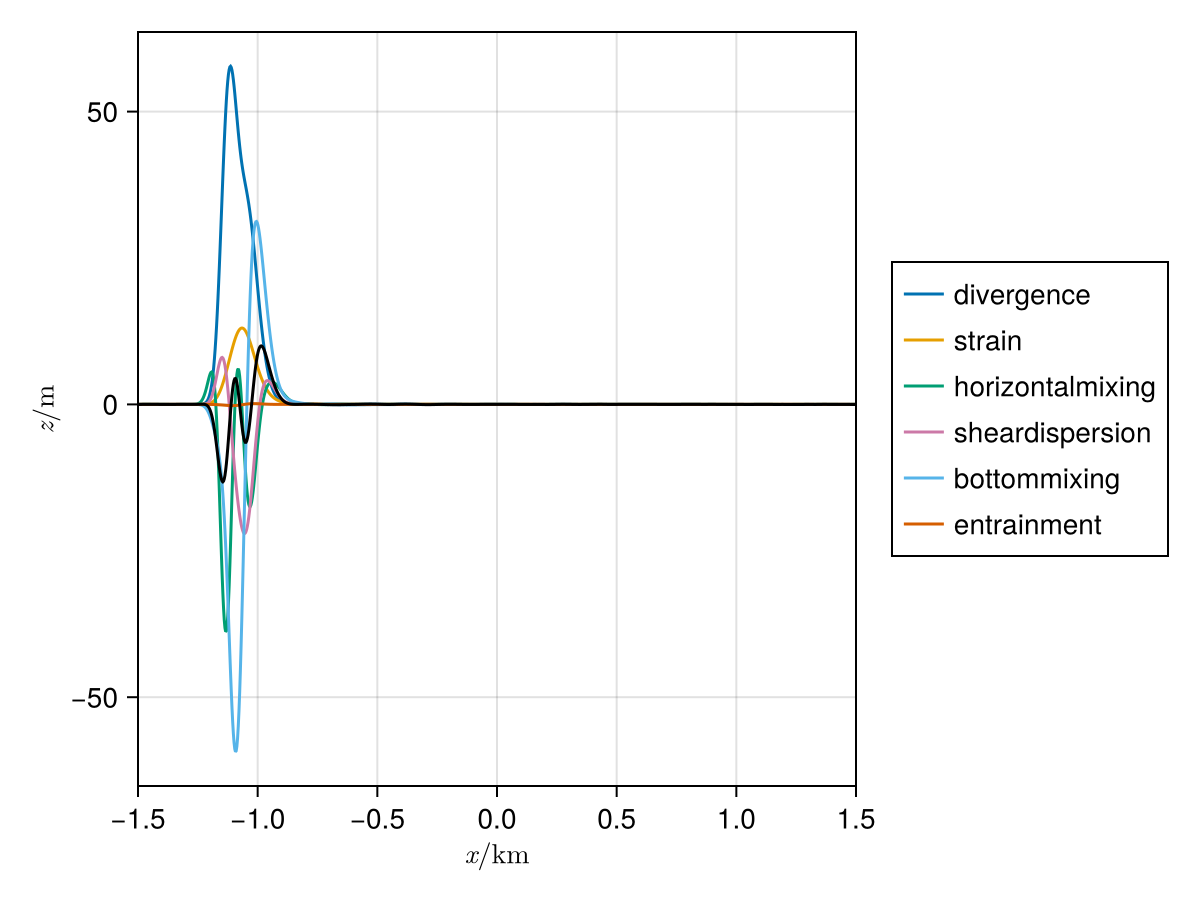

In [8]:
i = 1

run_ids = cooling_only.filenames
run_id = run_ids[i]

foldername = joinpath("../../scratch/turbulence-at-many-fronts", run_id)
SHEARDISPERSION = joinpath(foldername, "SHEARDISPERSION.jld2")
MLD = joinpath(foldername, "MLD.jld2")
iterations, times = iterations_times(SHEARDISPERSION)
sp = simulation_parameters(SHEARDISPERSION)
xsᶜ, xsᶠ, ysᶜ, ysᶠ, zsᶜ, zsᶠ = grid_nodes(SHEARDISPERSION)
s = normalized_time(SHEARDISPERSION)

n = 330

mld = get_field(MLD, "constant_mld", iterations[n])
ref = sp.α * (sp.Δb / sp.L)^2

advection = time_average_of(SHEARDISPERSION, "advection", iterations[end-10:end]) do field
    field ./ ref
end
background = time_average_of(SHEARDISPERSION, "background", iterations[end-10:end]) do field
    field ./ ref
end
divergence = time_average_of(SHEARDISPERSION, "divergence", iterations[end-10:end]) do field
    field ./ ref
end
strain = time_average_of(SHEARDISPERSION, "strain", iterations[end-10:end]) do field
    field ./ ref
end
horizontalmixing = time_average_of(SHEARDISPERSION, "horizontalmixing", iterations[end-10:end]) do field
    field ./ ref
end
sheardispersion = time_average_of(SHEARDISPERSION, "sheardispersion", iterations[end-10:end]) do field
    field ./ ref
end
bottommixing = time_average_of(SHEARDISPERSION, "bottommixing", iterations[end-10:end]) do field
    field ./ ref
end
entrainment = time_average_of(SHEARDISPERSION, "entrainment", iterations[end-10:end]) do field
    field ./ ref
end
total = divergence .+ strain .+ horizontalmixing .+ sheardispersion .+ bottommixing .+ entrainment .- advection .- background


fig = Figure()
ax = Axis(fig[1, 1];
    xlabel = L"x / \text{km}",
    ylabel = L"z / \text{m}",
    limits = (-sp.Lh/2000, sp.Lh/2000, nothing, nothing)
)

lns = [
    lines!(ax, xsᶠ ./ 1000, divergence),
    lines!(ax, xsᶠ ./ 1000, strain),
    lines!(ax, xsᶠ ./ 1000, horizontalmixing),
    lines!(ax, xsᶠ ./ 1000, sheardispersion),
    lines!(ax, xsᶠ ./ 1000, bottommixing),
    lines!(ax, xsᶠ ./ 1000, entrainment),
]
labels = [
    "divergence",
    "strain",
    "horizontalmixing",
    "sheardispersion",
    "bottommixing",
    "entrainment"
]
lines!(ax, xsᶠ ./ 1000, total; color=:black)
Legend(fig[1, 2], lns, labels)
fig

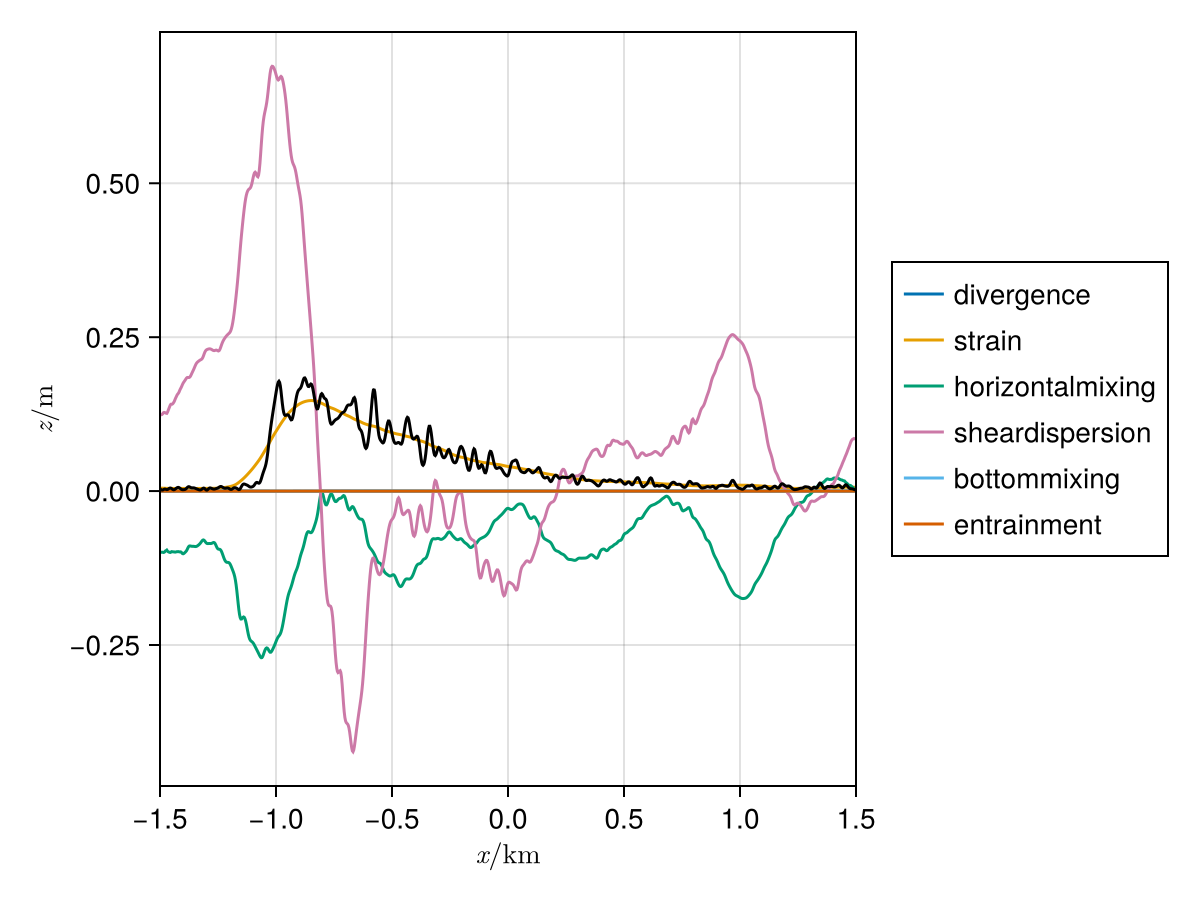

In [37]:
i = 4

run_ids = cooling_only.filenames
run_id = run_ids[i]

foldername = joinpath("../../scratch/turbulence-at-many-fronts", run_id)
SHEARDISPERSION = joinpath(foldername, "SHEARDISPERSION.jld2")
MLD = joinpath(foldername, "MLD.jld2")
iterations, times = iterations_times(SHEARDISPERSION)
sp = simulation_parameters(SHEARDISPERSION)
xsᶜ, xsᶠ, ysᶜ, ysᶠ, zsᶜ, zsᶠ = grid_nodes(SHEARDISPERSION)
s = normalized_time(SHEARDISPERSION)

n = 34

mld = get_field(MLD, "constant_mld", iterations[n])
ref = sp.α * (sp.Δb / sp.L)^2

Γ² = time_average_of(SHEARDISPERSION, "Γ", iterations[end-10:end]) do field
    field.^2 ./ (sp.Δb / sp.L)^2
end
advection = time_average_of(SHEARDISPERSION, "advection", iterations[end-2:end]) do field
    filt(field, 30) ./ ref
end
background = time_average_of(SHEARDISPERSION, "background", iterations[end-2:end]) do field
    filt(field, 30) ./ ref
end
divergence = time_average_of(SHEARDISPERSION, "divergence", iterations[end-2:end]) do field
    filt(field, 30) ./ ref
end
strain = time_average_of(SHEARDISPERSION, "strain", iterations[end-2:end]) do field
    filt(field, 30) ./ ref
end
horizontalmixing = time_average_of(SHEARDISPERSION, "horizontalmixing", iterations[end-2:end]) do field
    filt(field, 30) ./ ref
end
sheardispersion = time_average_of(SHEARDISPERSION, "sheardispersion", iterations[end-2:end]) do field
    filt(field, 30) ./ ref
end
bottommixing = time_average_of(SHEARDISPERSION, "bottommixing", iterations[end-2:end]) do field
    filt(field, 30) ./ ref
end
entrainment = time_average_of(SHEARDISPERSION, "entrainment", iterations[end-2:end]) do field
    filt(field, 30) ./ ref
end
total = divergence .+ strain .+ horizontalmixing .+ sheardispersion .+ bottommixing .+ entrainment .- advection .- background


fig = Figure()
ax = Axis(fig[1, 1];
    xlabel = L"x / \text{km}",
    ylabel = L"z / \text{m}",
    limits = (-sp.Lh/2000, sp.Lh/2000, nothing, nothing)
)

lns = [
    lines!(ax, xsᶠ ./ 1000, divergence),
    lines!(ax, xsᶠ ./ 1000, strain),
    lines!(ax, xsᶠ ./ 1000, horizontalmixing),
    lines!(ax, xsᶠ ./ 1000, sheardispersion),
    lines!(ax, xsᶠ ./ 1000, bottommixing),
    lines!(ax, xsᶠ ./ 1000, entrainment),
]
labels = [
    "divergence",
    "strain",
    "horizontalmixing",
    "sheardispersion",
    "bottommixing",
    "entrainment"
]
#lines!(ax, xsᶠ ./ 1000, total; color=:black)
lines!(ax, xsᶠ ./ 1000, Γ²; color=:black)
Legend(fig[1, 2], lns, labels)
fig

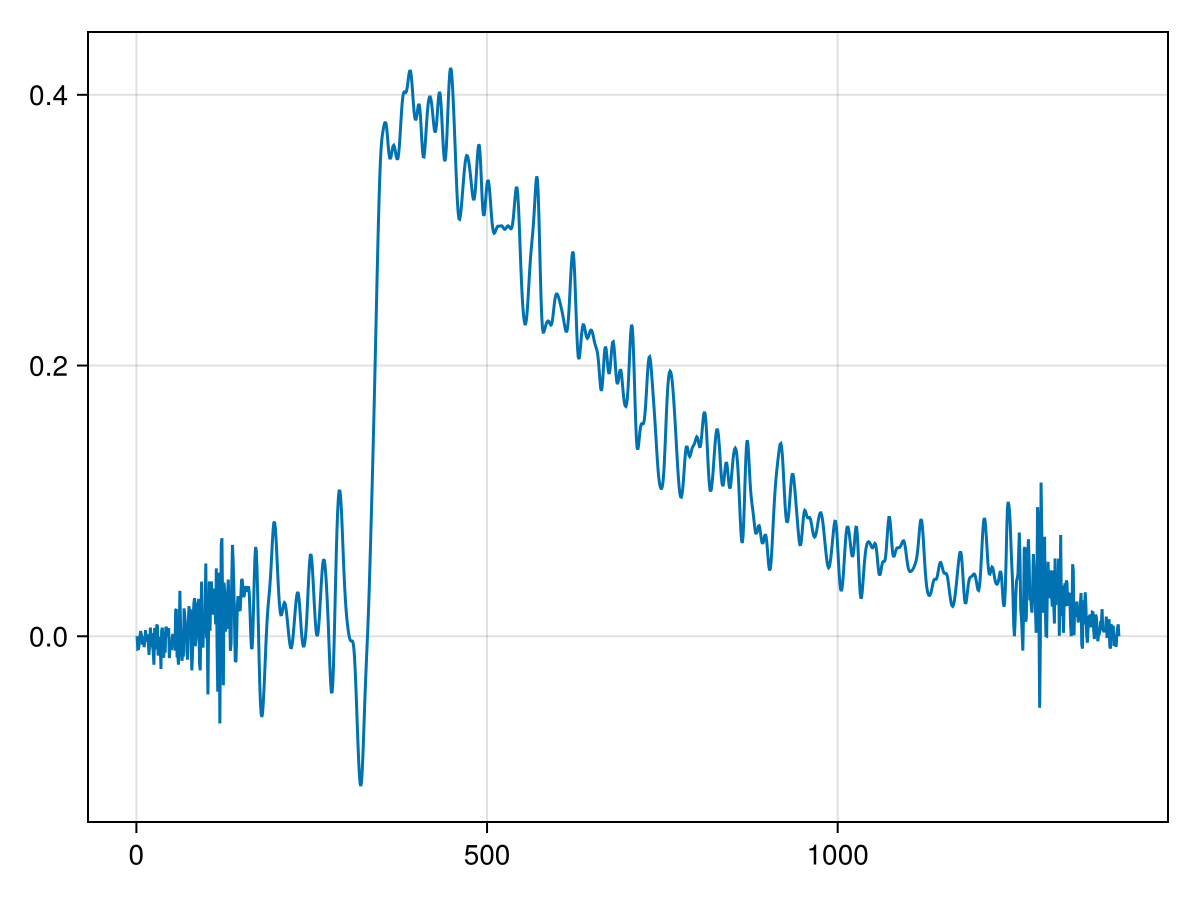

In [31]:
Γ = time_average_of(SHEARDISPERSION, "Γ", iterations[end-10:end]) do field
    field ./ (sp.Δb / sp.L)
end
lines(Γ)